In [1]:
suppressMessages(library(ArchR))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(ggplot2))
suppressMessages(library(cowplot))
suppressMessages(library(rtracklayer))

In [2]:
addArchRThreads(threads = 32)

Setting default number of Parallel threads to 32.



In [2]:
out_dir = '../../results/04_single_cell_access_atac/19_find_markers'

# create output directory
if (!dir.exists(out_dir)) {
  dir.create(out_dir, recursive = TRUE)
}

In [7]:
obj <- readRDS("../../results/04_single_cell_access_atac/14_create_seurat/seurat_atac_obj_with_clusters.Rds")

In [8]:
obj

An object of class Seurat 
172727 features across 2024 samples within 3 assays 
Active assay: GeneActivity (16887 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: ATAC, RNA
 2 dimensional reductions calculated: lsi, umap_atac

In [9]:
head(obj@meta.data)

,orig.ident,nCount_ATAC,nFeature_ATAC,Sample,TSSEnrichment,ReadsInTSS,ReadsInPromoter,PromoterRatio,PassQC,NucleosomeRatio,⋯,nDiFrags,DoubletScore,DoubletEnrichment,ReadsInPeaks,FRIP,nFrags_log10,ATAC_snn_res.1,seurat_clusters,nCount_GeneActivity,nFeature_GeneActivity
,<fct>,<dbl>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<fct>,<dbl>,<int>
mouse#GAGGCTCCAGAGTCGA,SeuratProject,33439,33439,mouse,10.229,10326,33420,0.1420073,1,4.658300,⋯,61008,227.8374,8.5,71761,0.3051712,5.070666,7,7,6403.629,15631
mouse#CTGTATTTCGTATAGC,SeuratProject,35815,35815,mouse,9.869,10102,33263,0.1442505,1,3.783669,⋯,57162,323.3062,14.2,76906,0.3337036,5.061814,3,3,6598.396,15718
mouse#TATCGAGGTAACGTAA,SeuratProject,35117,35117,mouse,10.541,10338,33123,0.1436471,1,3.778984,⋯,56647,323.3062,12.7,75636,0.3285122,5.061803,3,3,6524.608,15597
mouse#CGCAGGTAGAACGTCG,SeuratProject,30979,30979,mouse,9.835,8950,29135,0.1355709,1,4.227330,⋯,55373,323.3062,12.1,63549,0.2960366,5.031219,4,4,6413.499,15501
mouse#TTCTGTAGTATCCTTT,SeuratProject,30426,30426,mouse,8.935,8194,27820,0.1300267,1,3.927591,⋯,53227,153.5944,6.8,63975,0.2993655,5.029294,4,4,6445.644,15409
mouse#GCTTGCTGTTGTGAGG,SeuratProject,32349,32349,mouse,11.220,9678,30277,0.1502014,1,4.268308,⋯,51956,323.3062,11.5,67739,0.3364074,5.003409,4,4,6552.102,15375


In [10]:
DefaultAssay(obj) <- "RNA"

In [35]:
features <- list("Basal" = c("Aqp3", "Icam1", "Krt17", "Krt5", "Krt15",
                 "Sfn", "Perp", "Fxyd3", "Sdc1", "Gstm2",
                 "F3", "Epas1", "Abi3bp", "Adh7", "Id1",
                 "Upk1b", "Hspa1a", "Dapl1", "Hspb1", "Zfp296",
                 "Dcn", "Rplp0", "Fam107b", "Tacstd2", "Rpl13",
                 "Sat1", "Sult1d1", "Hpgd", "S100a14", "Rps18",
                 "Emp1", "Sgk1", "Gsta4", "Rps4x", "Rps5",
                 "Oat", "Rps8", "S100a16", "Phlda3", "Dusp1",
                 "Crlf1", "Sh3bgrl3", "Rps2", "Junb", "Pcolce",
                 "Cotl1", "Sord", "Igfbp7",  "Rpl8",  "Rpl4"))

obj <- AddModuleScore(object = obj, features, 
assay = "RNA", 
name = "Basal_Marker_Score_", seed = 1, slot = "data")

In [36]:
features <- list("Club" = c("Scgb1a1", "Bpifa1", "Scgb3a2", "Sftpd", "Alox15",
 "Pon1", "Cyp4a12b", "Wfdc1", "Mgst1", "Akr1c18", "Sftpa1", "Lypd2", "Ces1f", "Gsto1",
 "Tst", "Ffar4", "Hp", "Chad", "Selenbp1", "Mgat3", "Gabrp"))

obj <- AddModuleScore(object = obj, features, 
assay = "RNA", 
name = "Club_Marker_Score_", seed = 1, slot = "data")

In [49]:
features <- list("Ciliated" = c("AU040972", "Tmem212", "Dynlrb2",
"Ccdc153",
"Tppp3",
"1110017D15Rik",
"Fam183b",
"Sec14l3",
"Pltp",
"Rsph1",
"Mlf1",
"2410004P03Rik",
"Tekt1",
"Cdh26",
"Cdhr3",
"Nme5",
"Ccdc17",
"Adam8",
"Cyp2s1",
"1700007K13Rik",
"Tm4sf1",
"Elof1",
"Ly6a",
"Sntn",
"Ppil6",
"Ifitm1",
"Tctex1d4",
"Aldh3b1",
"Lrrc48",
"Foxj1",
"1700026L06Rik",
"Csrp2",
"Pifo",
"Acot1",
"Dnali1",
"Ccdc113",
"Pcp4l1",
"Spag6",
"Capsl",
"Lrrc51",
"2610028H24Rik",
"Ldlrad1",
"Stmnd1",
"1700024G13Rik",
"Dmkn",
"Ccdc78",
"Chchd6",
"1700016K19Rik",
"Calml4",
"Vpreb3",
"Odf3b",
"Ak7",
"1700003M02Rik",
"1700026D08Rik",
"Lrrc23",
"BC051019",
"Tubb4b",
"Enkur",
"Bphl",
"Spata18",
"Fam216b",
"Riiad1",
"1700088E04Rik",
"1700007G11Rik",
"Rsph4a",
"Fam47e",
"Agr3",
"Fbxo36",
"1700001C02Rik",
"Cmbl",
"Spag16",
"Bok",
"Ift43",
"Ubxn10",
"Tekt4",
"Ccdc108",
"Erich2",
"6820408C15Rik",
"Prdx5",
"Fam92b",
"Smim5",
"Hdc",
"Serpina9",
"Ly6c1",
"Aldh1a1",
"Fhl1",
"4833427G06Rik",
"Rfk",
"Dnaic2",
"Ppp1r36",
"Ak8",
"B9d1",
"Chchd10",
"Zmynd10",
"Rsph9",
"Nek5",
"Gm973",
"Ccdc39",
"Efhc1",
"Hsph1",
"Tuba1b",
"Ubxn11",
"Slc23a2",
"Spa17",
"Nat9",
"Efcab10",
"Cd177",
"Hsp90aa1",
"Iqca",
"Dync2li1",
"Ruvbl1",
"Ppp1r32",
"Spef1",
"Ccdc81",
"Dnajb13",
"Acox2",
"Fhad1",
"Spag8",
"Nudc",
"Ccdc146",
"Pih1d2",
"Vwa3a",
"Fam179a",
"Fth1",
"Ccdc151",
"Lrrc36",
"Cxcl17",
"Kif9",
"Ccdc37",
"Mapk15",
"Lhb",
"Cd82",
"Fam161a",
"Rabl2",
"Fank1",
"Wdr63",
"Glipr1",
"Zfp474",
"Lgals3bp",
"Dpcd",
"Ttc29",
"Ttc16",
"Mdh1b",
"Ruvbl2",
"Gipc2",
"Arc",
"Mak",
"Dcdc2b",
"Ccdc30",
"1700028P14Rik",
"Mycbp",
"Oscp1",
"Morn5",
"Iqcg",
"Eno4",
"Ift74",
"Lrrc34",
"Cetn4",
"Ankrd66",
"Dnajc15",
"Ulk4",
"Tbata",
"Traf3ip1",
"Akr1b8",
"6430531B16Rik",
"Armc4",
"Maats1",
"Plekhb1",
"Meig1",
"Morn3",
"Lrrc71",
"1110004E09Rik",
"Ift88",
"Timp4",
"Fam166b",
"Ccdc121",
"Usp18",
"Ccdc33",
"Slc23a1",
"Gm166",
"1810037I17Rik",
"Syt5",
"Dnaaf1",
"Mns1",
"Dusp14",
"Wdr78",
"Dynll1",
"Gas8",
"Ccdc114",
"Crip2",
"Ctxn1",
"1700040L02Rik",
"Tcp11",
"Kif19a",
"Ccdc65",
"Tmem107",
"Adgb",
"Cib1",
"Dnaic1",
"Odc1",
"Dnaaf3",
"Cdkl4",
"Mrps17",
"Wdr34",
"Slc9a3r1",
"Kcnmb2",
"Swi5",
"Plin5",
"Zc2hc1a",
"Jam3",
"Lrrc6",
"Sptlc3",
"Hydin",
"Fam216a",
"4932443I19Rik",
"Ankrd42",
"Wdr60",
"Lrrc45",
"Spef2",
"Ezr",
"Wnt11",
"Fam213a",
"Gtsf1l",
"Lbp",
"Wdr95",
"Syne1",
"Abhd3",
"Tctex1d2",
"Ttc39a",
"Lrrc46",
"Stk33",
"Slc2a12",
"Mipep",
"Mst1",
"Myl4",
"Oaz2",
"Ttc12",
"Ccdc176",
"Ift57",
"Wdr54",
"4930444P10Rik",
"Tuba1a",
"1700013F07Rik",
"Mxra8",
"D430036J16Rik",
"Spag17",
"Ddo",
"Sri",
"Ctsk",
"Calm1",
"4430402I18Rik",
"2310007B03Rik",
"Psmc3ip",
"Nudt4",
"Ttll9",
"Dusp18",
"Rfc2",
"1700029J07Rik",
"Naga",
"Akap14",
"Atp2a2",
"Pttg1",
"Casc1",
"Ccdc60",
"Dydc2",
"Lrrc10b",
"Mycbpap",
"1700001L19Rik",
"Dlec1",
"Kif6",
"Ropn1l",
"Eml2",
"Ech1",
"Slc1a4",
"Sftpc",
"1700101E01Rik",
"Efcab1",
"Sirt3",
"Pacrg",
"Cdc14a",
"Itln1"))

obj <- AddModuleScore(object = obj, features, 
assay = "RNA", 
name = "Ciliated_Marker_Score_", seed = 1, slot = "data")

Warning message:
“The following features are not present in the object: 1700007K13Rik, Tctex1d4, Lrrc48, 1700026L06Rik, 1700003M02Rik, 1700026D08Rik, 1700007G11Rik, 1700001C02Rik, Ccdc108, Fam92b, 4833427G06Rik, Dnaic2, Fam179a, Ccdc151, Ccdc37, Wdr63, 1700028P14Rik, 6430531B16Rik, Armc4, Maats1, 1110004E09Rik, Gm166, Wdr78, Ccdc114, 1700040L02Rik, Dnaic1, Wdr34, Slc9a3r1, Lrrc6, 4932443I19Rik, Wdr60, Fam213a, Tctex1d2, Ccdc176, 1700013F07Rik, 4430402I18Rik, 2310007B03Rik, 1700001L19Rik, 1700101E01Rik, not searching for symbol synonyms”


In [51]:
features <- list("Tuft" = c("Lrmp","Gnat3",
"Gnb3",
"Plac8",
"Trpm5",
"Gng13",
"Ltc4s",
"Rgs13",
"Hck",
"Alox5ap",
"Avil",
"Alox5",
"Ptpn6",
"Atp2a3",
"Plk2",
"Zfp428",
"Ethe1",
"Mctp1",
"Fxyd6",
"1810046K07Rik",
"Pik3r5",
"Cd300lf",
"Rassf6",
"Dclk1",
"Spib",
"Pik3cg",
"Pde2a",
"Matk",
"Vav1",
"Sh2d7",
"Bmx",
"Fyb",
"Ccdc28b",
"Ptpn18",
"Bpgm",
"Itgb7",
"Ccdc109b",
"Anxa4",
"Rgs2",
"Tspan6",
"Prss53",
"Ly6g6f",
"Inpp5d",
"Ivns1abp",
"Nkd1",
"Sh3bgrl",
"Pou2f3",
"Sox9",
"Chn2",
"Krt18",
"Calm2",
"Kctd12",
"Etv1",
"Coprs",
"Cd47",
"Espn",
"Tmem245",
"Pitpnc1",
"Hap1",
"Reep5",
"H2afj",
"Selm"))

obj <- AddModuleScore(object = obj, features, 
assay = "RNA", 
name = "Tuft_Marker_Score_", seed = 1, slot = "data")

Warning message:
“The following features are not present in the object: Lrmp, 1810046K07Rik, Ccdc109b, H2afj, Selm, not searching for symbol synonyms”


In [53]:
features <- list("Neuroendocrine" = c("Chga", "Calca", "Cxcl13", "Scg2", "Nov",
"Scg5", "Pcsk1", "Dnajc12", "Uchl1", "Ddc", "Snca", "Snap25", "Cib3",
"Bex2", "Guk1", "Chgb", "Ascl1", "Ngf", "Cplx2", "Igfbp5",
"Pkib", "Lrp11", "Tcerg1l", "Rbp4",
"Mthfd2",
"Cd9",
"Meis2",
"Ly6h",
"Tmem158",
"Cacna2d1",
"Syt7",
"Ptp4a3"))

obj <- AddModuleScore(object = obj, features, 
assay = "RNA", 
name = "Neuroendocrine_Marker_Score_", seed = 1, slot = "data")

Warning message:
“The following features are not present in the object: Nov, not searching for symbol synonyms”


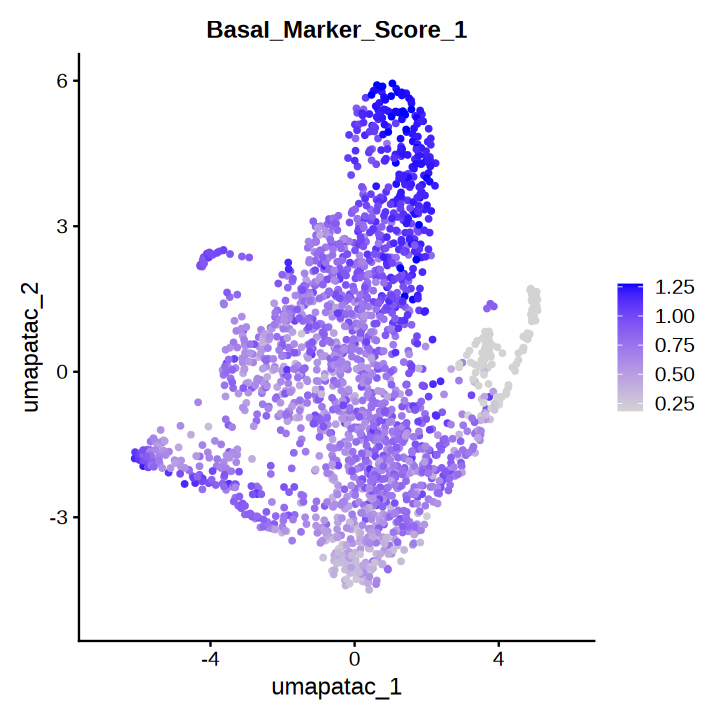

In [47]:
options(repr.plot.height = 6, repr.plot.width = 6)

FeaturePlot(
  obj,
  features = "Basal_Marker_Score_1",
  cols = c("lightgrey", "blue"),
  reduction = "umap_atac",
  max.cutoff = "q99",
  min.cutoff = "q01",
  pt.size = 1
) +
  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5, size = 14))

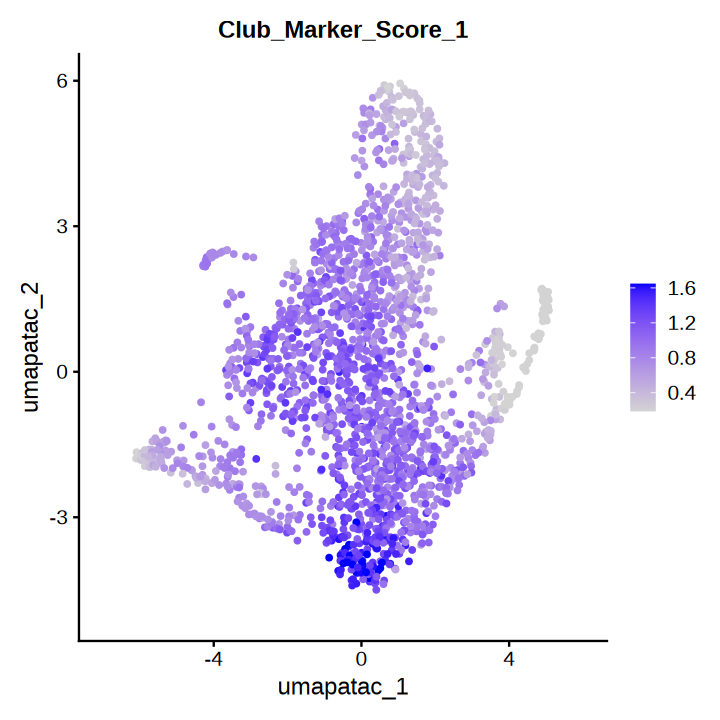

In [48]:
FeaturePlot(
  obj,
  features = "Club_Marker_Score_1",
  cols = c("lightgrey", "blue"),
  reduction = "umap_atac",
  max.cutoff = "q99",
  min.cutoff = "q01",
  pt.size = 1
) +
  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5, size = 14))

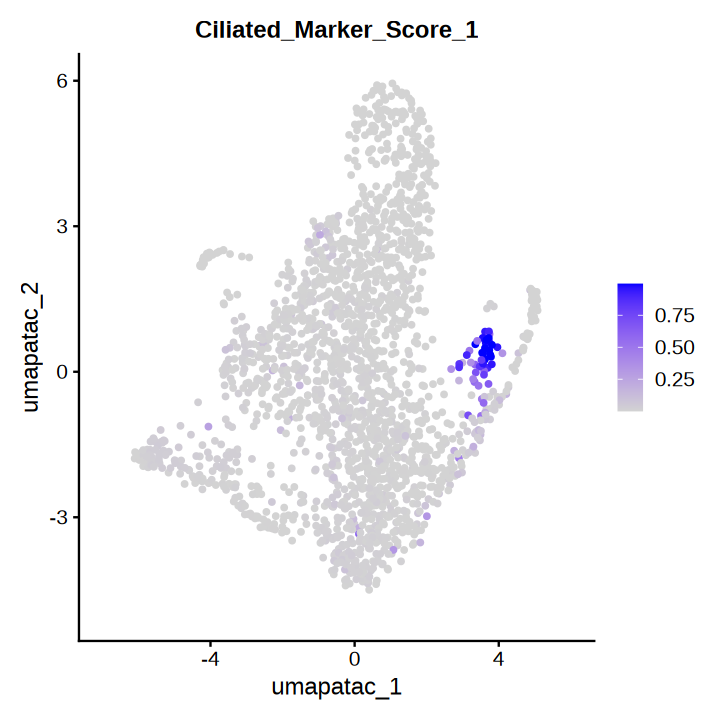

In [50]:
FeaturePlot(
  obj,
  features = "Ciliated_Marker_Score_1",
  cols = c("lightgrey", "blue"),
  reduction = "umap_atac",
  max.cutoff = "q99",
  min.cutoff = "q01",
  pt.size = 1
) +
  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5, size = 14))

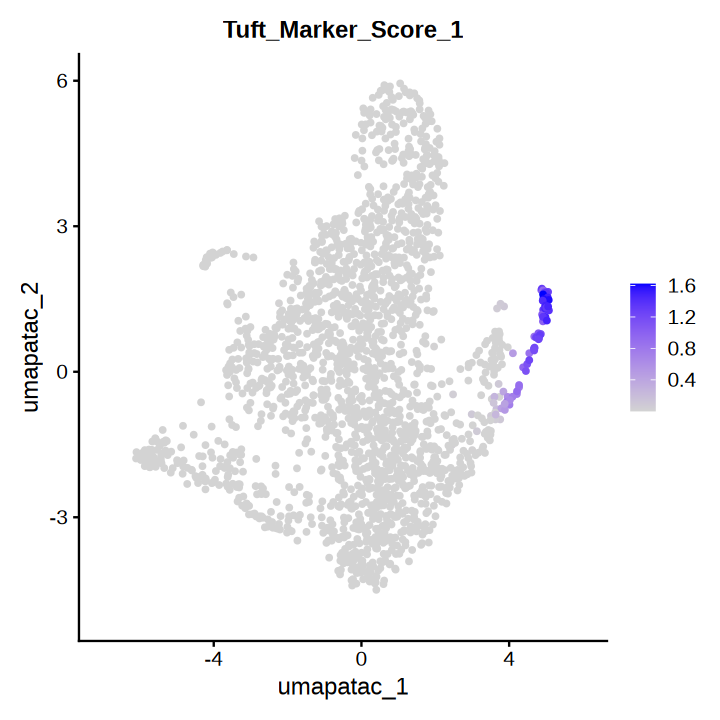

In [52]:
FeaturePlot(
  obj,
  features = "Tuft_Marker_Score_1",
  cols = c("lightgrey", "blue"),
  reduction = "umap_atac",
  max.cutoff = "q99",
  min.cutoff = "q01",
  pt.size = 1
) +
  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5, size = 14))

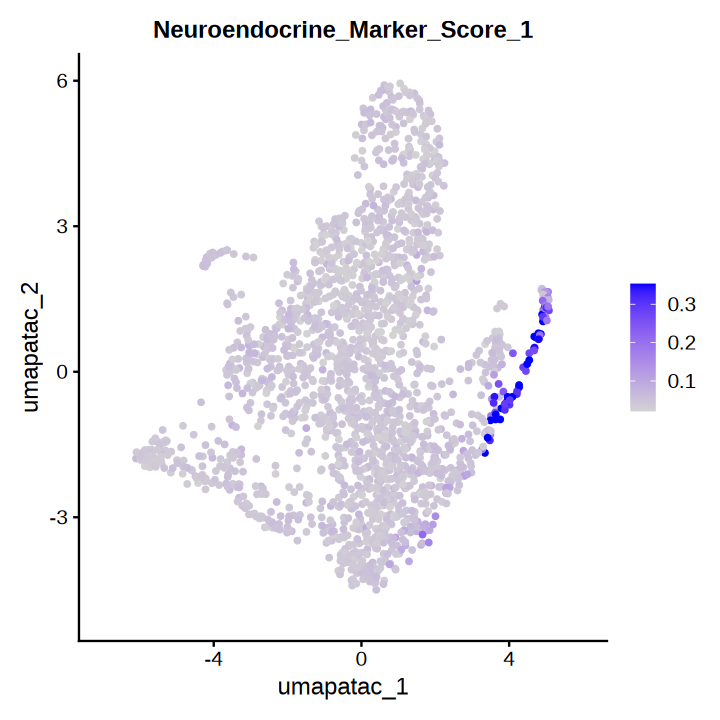

In [54]:
FeaturePlot(
  obj,
  features = "Neuroendocrine_Marker_Score_1",
  cols = c("lightgrey", "blue"),
  reduction = "umap_atac",
  max.cutoff = "q99",
  min.cutoff = "q01",
  pt.size = 1
) +
  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5, size = 14))

In [55]:
features <- list("Ionocyte" = c("Stap1",
"Gm933",
"Ascl3",
"Foxi1",
"Atp6v0d2",
"Moxd1",
"Gnas",
"Ldhb",
"Rasd1",
"P2ry14",
"Tfcp2l1",
"Cd81",
"Cftr",
"Slc12a2",
"Asgr1",
"Parm1",
"Atp6v1e1",
"Iqgap1",
"Rbpms"))

obj <- AddModuleScore(object = obj, features, 
assay = "RNA", 
name = "Ionocyte_Marker_Score_", seed = 1, slot = "data")

Warning message:
“The following features are not present in the object: Gm933, not searching for symbol synonyms”


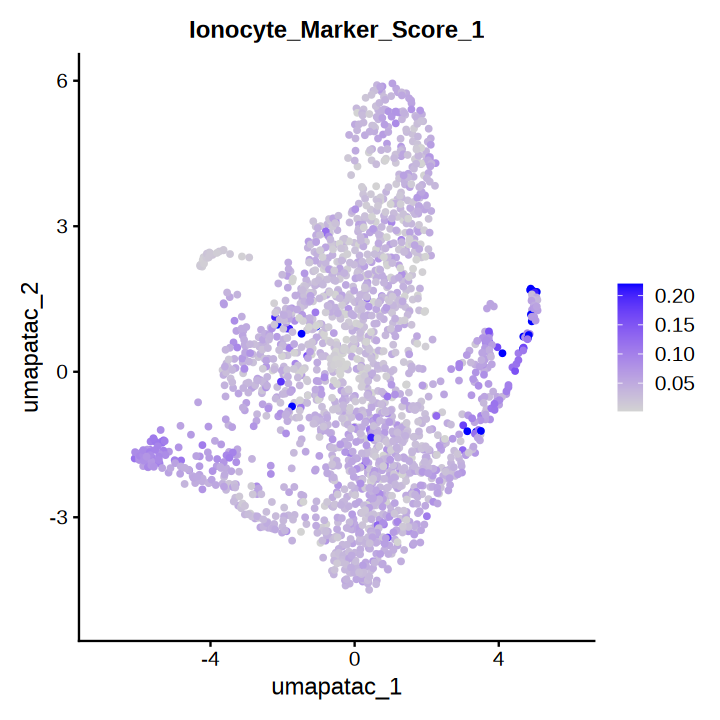

In [56]:
FeaturePlot(
  obj,
  features = "Ionocyte_Marker_Score_1",
  cols = c("lightgrey", "blue"),
  reduction = "umap_atac",
  max.cutoff = "q99",
  min.cutoff = "q01",
  pt.size = 1
) +
  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5, size = 14))

In [57]:
features <- list("Goblet" = c("Gp2",
"Tff2",
"Dmbt1",
"Scgb3a1",
"Sbpl",
"Dcpp3",
"Pglyrp1",
"Tmed3",
"Wfdc18",
"Agr2",
"Lman1l",
"Serpinb11",
"Ltf",
"Tff1",
"Muc5b",
"Kcnn4",
"Cgref1",
"Bace2",
"Fkbp11",
"Cldn10",
"Dusp5",
"Isg20",
"Creb3l1",
"P2rx4",
"Kcne3",
"Fgl2",
"Copz2",
"Nans",
"Rrbp1",
"Lmcd1",
"Smim14_ENSMUSG00000037822",
"P4hb",
"Dnajc3",
"Nucb2",
"Mfsd4",
"Tpd52l1",
"Bcat2",
"Edem1",
"Msln",
"Sdf2l1",
"Qsox1",
"Gmppa",
"Ppp1r1b",
"Azgp1",
"Serp1",
"Ostc",
"Spdef",
"Kdelr3",
"Creb3l4",
"Lrrc26",
"Rab4a",
"Vimp"))

obj <- AddModuleScore(object = obj, features, 
assay = "RNA", 
name = "Goblet_Marker_Score_", seed = 1, slot = "data")

Warning message:
“The following features are not present in the object: Smim14_ENSMUSG00000037822, Mfsd4, Vimp, not searching for symbol synonyms”


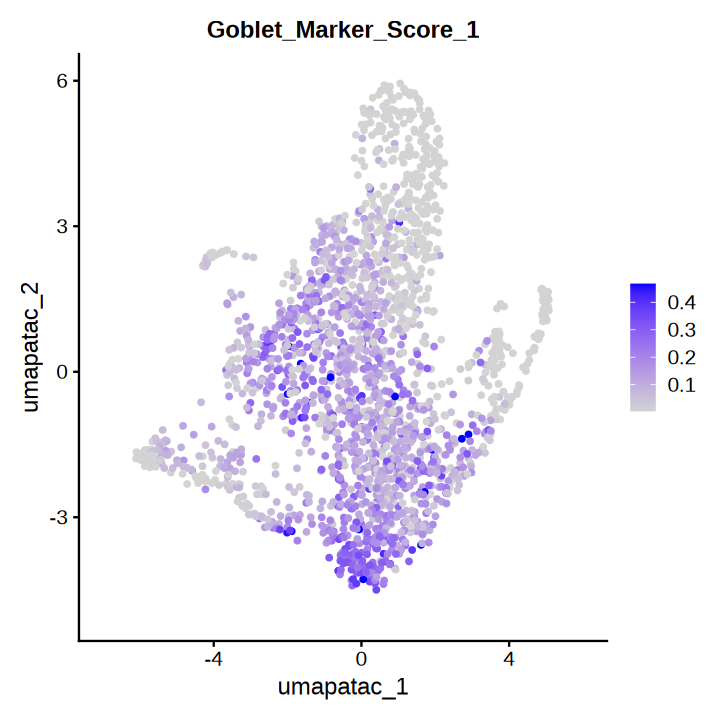

In [58]:
FeaturePlot(
  obj,
  features = "Goblet_Marker_Score_1",
  cols = c("lightgrey", "blue"),
  reduction = "umap_atac",
  max.cutoff = "q99",
  min.cutoff = "q01",
  pt.size = 1
) +
  theme(legend.position = "right",
        plot.title = element_text(hjust = 0.5, size = 14))

In [60]:
# Find markers using gene activity scores
all.markers <- FindAllMarkers(obj, 
                                assay = "RNA",
                              only.pos = TRUE, 
                              min.pct = 0.25, 
                              logfc.threshold = 0.25)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10



In [61]:
# write markers to excel file and split by cluster
library(openxlsx)

split_col <- "cluster"
sheets <- split(all.markers, all.markers[[split_col]])

wb <- createWorkbook()

for (nm in names(sheets)) {
  addWorksheet(wb, nm)
  writeDataTable(wb, nm, sheets[[nm]])
}

saveWorkbook(wb, glue::glue("{out_dir}/atac_clusters_gene_activity_markers.xlsx"), overwrite = TRUE)

In [62]:
saveRDS(obj, file = glue::glue("{out_dir}/seurat_atac_obj_with_marker_scores.Rds"))

In [3]:
obj <- readRDS(glue::glue("{out_dir}/seurat_atac_obj_with_marker_scores.Rds"))

In [4]:
df <- obj@meta.data

In [6]:
df <- df[, c("Basal_Marker_Score_1", "Club_Marker_Score_1",
"Ciliated_Marker_Score_1", "Tuft_Marker_Score_1",
"Neuroendocrine_Marker_Score_1", "Ionocyte_Marker_Score_1",
"Goblet_Marker_Score_1")]

In [7]:
head(df)

,Basal_Marker_Score_1,Club_Marker_Score_1,Ciliated_Marker_Score_1,Tuft_Marker_Score_1,Neuroendocrine_Marker_Score_1,Ionocyte_Marker_Score_1,Goblet_Marker_Score_1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
mouse#GAGGCTCCAGAGTCGA,1.1660783,0.1664142,-0.004258977,-0.01789694,0.06516792,0.11670215,-0.11643719
mouse#CTGTATTTCGTATAGC,0.9047839,0.7458393,-0.006521322,-0.04564897,0.04869434,0.03401068,0.01314981
mouse#TATCGAGGTAACGTAA,1.0752214,0.6821365,-0.013413253,-0.03643436,0.03639699,0.01890323,-0.02324707
mouse#CGCAGGTAGAACGTCG,1.0248177,0.7951197,-0.015304411,-0.02390166,0.06973183,0.03549219,-0.04010561
mouse#TTCTGTAGTATCCTTT,0.6523784,1.2331648,0.011927238,-0.04527641,0.06829241,0.05749235,0.07192477
mouse#GCTTGCTGTTGTGAGG,1.0189504,0.7067177,-0.013824658,-0.01147132,0.02351136,0.08133213,-0.03405685


In [8]:
write.csv(df, file = glue::glue("{out_dir}/marker_scores_per_cell.csv"))

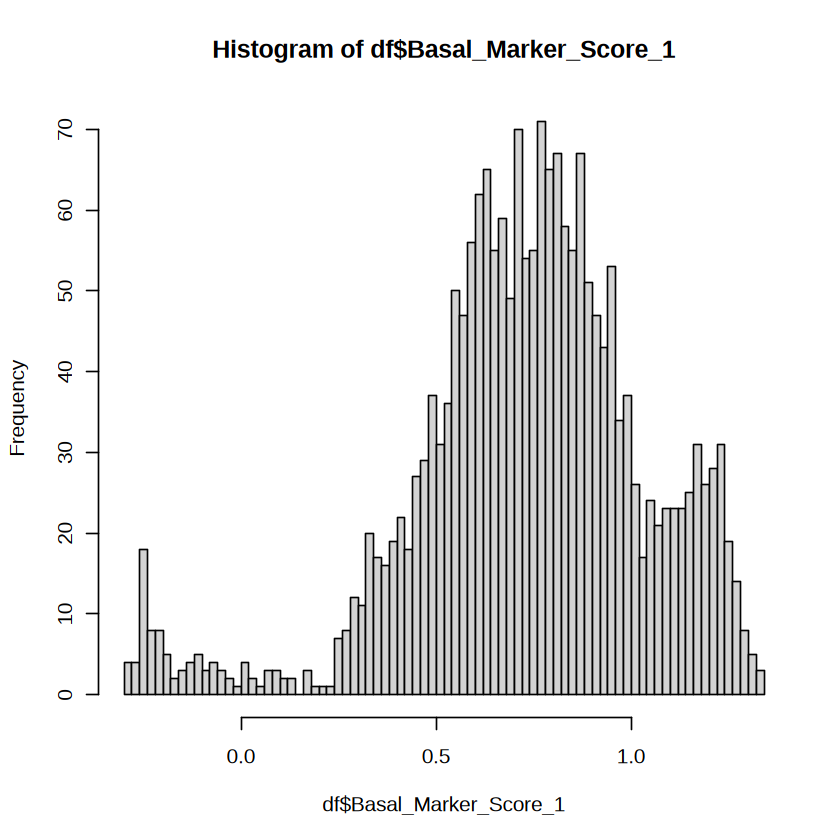

In [10]:
hist(df$Basal_Marker_Score_1, breaks = 100)

In [17]:
n_basal <- sum(df$Basal_Marker_Score_1 > 1.0)
n_club <- sum(df$Club_Marker_Score_1 > 1.0)

In [21]:
n_basal

[1] 347

In [20]:
n_club

[1] 724

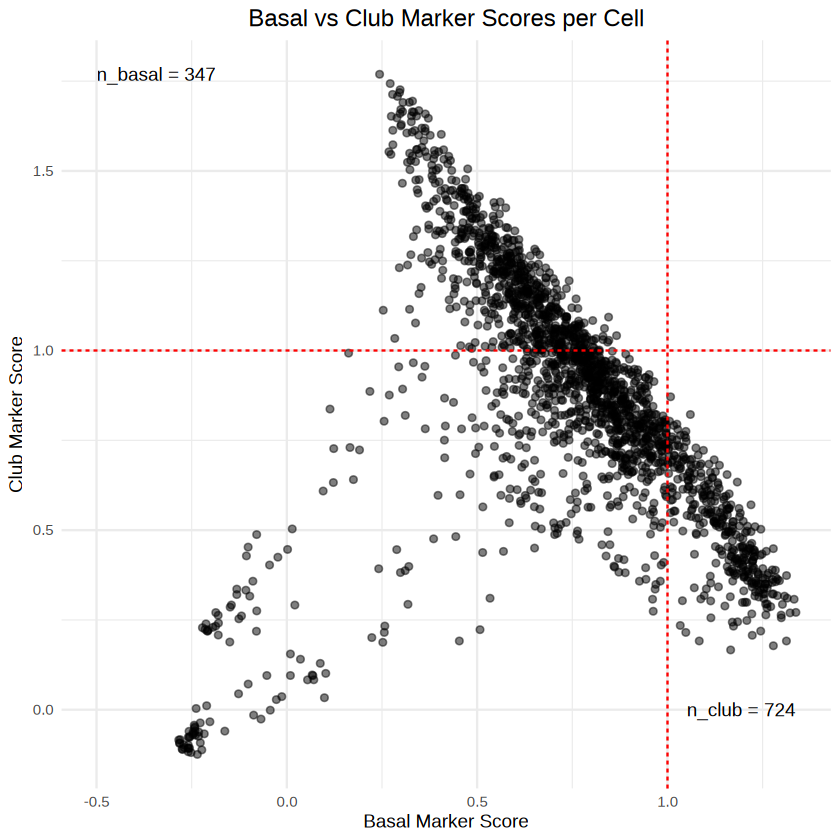

In [24]:
# add annotation for n_basal and n_club
ggplot(df, aes(x = Basal_Marker_Score_1, y = Club_Marker_Score_1)) +
  geom_point(alpha = 0.5) +
  geom_hline(yintercept = 1.0, linetype = "dashed", color = "red") +
  geom_vline(xintercept = 1.0, linetype = "dashed", color = "red") +
  theme_minimal() +
  xlab("Basal Marker Score") +
  ylab("Club Marker Score") +
  ggtitle("Basal vs Club Marker Scores per Cell") +
  theme(plot.title = element_text(hjust = 0.5, size = 14)) +
  annotate("text", x = -0.5, y = max(df$Club_Marker_Score_1), 
  label = paste("n_basal =", n_basal), hjust = 0) +
  annotate("text", x = max(df$Basal_Marker_Score_1), y = 0, 
  label = paste("n_club =", n_club), hjust = 1)